In [ ]:
import pandas as pd, numpy as np
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from plot_style import *


In [3]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def linear_path(Psi, start_idx, end_idx, n_grid=10):
    return np.linspace(Psi[start_idx], Psi[end_idx], num=n_grid)

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query /= scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=27, tau=0.2):
    nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi)
    distances, indices = nn.kneighbors(gamma)
    a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
    points = Z[indices, :]; z_hat = np.sum(a[:, :, None] * points, axis=1)
    z_hat[0], z_hat[-1] = Z[start_idx], Z[end_idx]
    return z_hat

def lift_validation(z_hat, Z):
    nn = NearestNeighbors(n_neighbors=1); nn.fit(Z)
    dNN, _ = nn.kneighbors(z_hat)
    return dNN

def latent_path_length(coords):
    diffs = np.diff(coords, axis=0)
    return np.linalg.norm(diffs, axis=1).sum()

def path_smoothness(coords):
    if len(coords) < 3:
        return 0.0
    second_diff = coords[2:] - 2 * coords[1:-1] + coords[:-2]
    return np.sum(np.linalg.norm(second_diff, axis=1) ** 2)

def density_weighted_cost(coords, V_path, beta):
    diffs = np.diff(coords, axis=0)
    edge_lengths = np.linalg.norm(diffs, axis=1)
    V_mid = 0.5 * (V_path[:-1] + V_path[1:])
    return np.sum(edge_lengths * np.exp(beta * V_mid))

def direction_change(coords):
    d = np.diff(coords, axis=0)
    u = d / np.linalg.norm(d, axis=1)[:, None]
    return np.sum( np.linalg.norm(np.diff(u, axis=0), axis=1)**2 )

def lin_interior_min_mean(Psi, s, e, h, scale, n=40):
    lin = np.linspace(Psi[s], Psi[e], n)[1:-1]
    rho_lin, _ = latent_density_at_points(lin, Psi, h, scale)
    return rho_lin.min(), rho_lin.mean(), nn_dist_to_cloud(Psi, lin).max(), np.argmin(rho_lin)

def nn_dist_to_cloud(Psi, pts):
    return np.array([np.min(np.linalg.norm(Psi - p, axis=1)) for p in pts])

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query = rho_query/scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def interior_min_mean(rho, idx_path):
    interior = idx_path[1:-1] if len(idx_path) > 2 else idx_path
    return rho[interior].min(), rho[interior].mean()

In [4]:
K_GRAPH = 15
BETA = 1.5
N_DIFFUSION_COORDS = 3
EPS_DIFFUSION = 3
N_LINEAR_GRID = 40
M_LIFT = 22


df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]

diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]

h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

endpoint_pairs = {"2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"), "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2021 Fiscal Tightening": ("2019-04-01", "2022-04-01"), "1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01")}
pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

# Phase 8: Robustness checks
(i) Vary $k$ in the graph construction

In [25]:
rows = []

for name, (s, e) in pairs.items():
    
    ks = [5, 10, 15, 20, 25, 30]
    for k in ks:
        A_dist = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
        A_dist_sym = A_dist.maximum(A_dist.T)
        p = graph_path(A_dist_sym, BETA, V, s, e)
        P = Psi[p]; V_path = V[p]
        imin, imean = interior_min_mean(rho, p)

        rows.append({
                "k": k,
                "event": name,
                "number_points": P.shape[0],
                "interior_minimum_density": imin,
                "interior_mean_density": imean,
                "latent_path_length": latent_path_length(P),
                "density_weighted_cost": density_weighted_cost(P, V_path, beta=BETA),
                "smoothness": path_smoothness(P),
                "direction_change": direction_change(P)
            })

knn_res = pd.DataFrame(rows)
print(knn_res.round(4).to_string(index=False))

 k                                 event  number_points  interior_minimum_density  interior_mean_density  latent_path_length  density_weighted_cost  smoothness  direction_change
 5               2006 benign -> 2008 GFC             18                    0.1158                 1.2115              1.2415                48.6152      0.3636           16.6775
10               2006 benign -> 2008 GFC             13                    0.2093                 1.1677              1.2020                33.6883      0.4833            5.9251
15               2006 benign -> 2008 GFC             10                    0.3120                 1.3036              1.1211                25.4583      0.4589            2.8580
20               2006 benign -> 2008 GFC              9                    0.3248                 1.3928              1.1035                24.9362      0.4692            3.6526
25               2006 benign -> 2008 GFC              8                    0.3248                 1.2434      

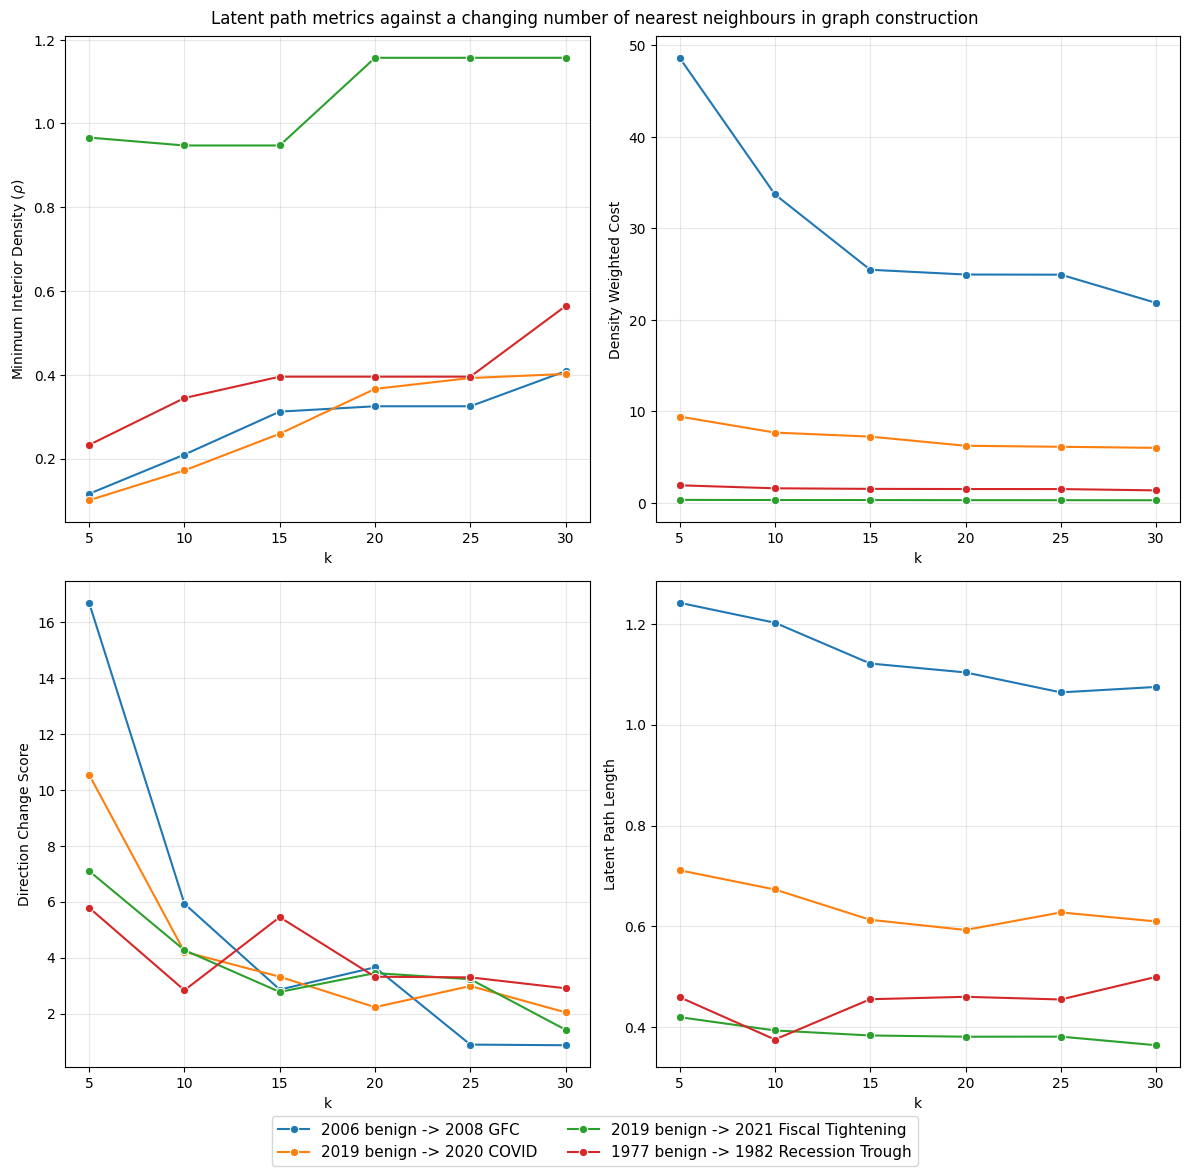

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12,12))
axes_flat = axes.flatten()

fig.suptitle("Latent path metrics against a changing number of nearest neighbours in graph construction")
metrics = ['interior_minimum_density', 'density_weighted_cost', 'direction_change', 'latent_path_length']

metric_names_clean = {
    "interior_minimum_density": r"Minimum Interior Density ($\rho$)",
    "density_weighted_cost": "Density Weighted Cost",
    "direction_change": "Direction Change Score",
    "latent_path_length": "Latent Path Length"}

for i, metric in enumerate(metrics):
    sns.lineplot(data=knn_res, x='k', y=metric, hue='event', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(metric_names_clean.get(metric, metric))
    axes_flat[i].grid(alpha=0.3)

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("./figures/robustness_k.pdf")
plt.show()

(ii) Vary $\beta$

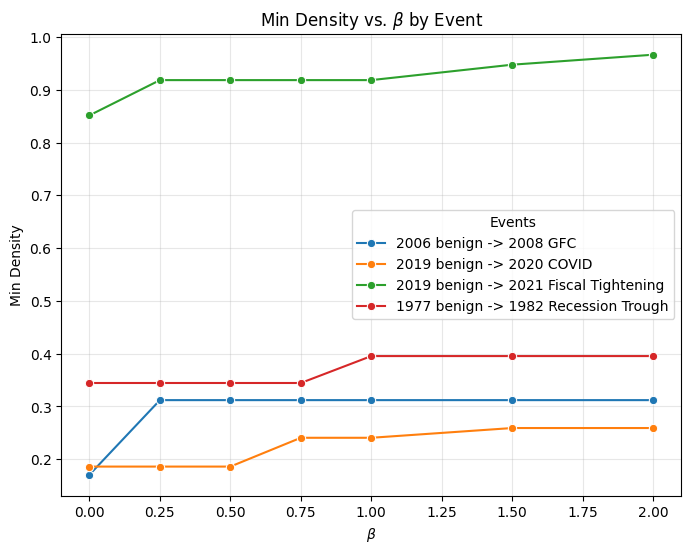

In [8]:
beta_records = []
betas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

for event, (start_idx, end_idx) in pairs.items():
    for beta in betas:
        idx_graph = graph_path(A_dist_sym, beta=beta, V=V, start=start_idx, end=end_idx)
        if len(idx_graph) > 2:
            interior_density = rho[idx_graph][1:-1]
        else:
            interior_density = rho[idx_graph]
        beta_records.append({"event": event, "beta": beta, "min_density": interior_density.min(), "mean_density": interior_density.mean()})

beta_df = pd.DataFrame(beta_records)
plt.figure(figsize=(8,6))
sns.lineplot(data=beta_df, x='beta', y='min_density', hue='event', marker='o', palette='tab10')

plt.xlabel(r'$\beta$'); plt.ylabel('Min Density')
plt.title(r'Min Density vs. $\beta$ by Event')
plt.legend(title='Events'); plt.grid(alpha=0.3)
plt.show()

(iii) Vary the diffusion bandwidth slightly

In [ ]:
eps_values = [0.1, 0.5, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 10.0]
path_rows = []; embedding_rows = []; embedding_store = {}
path_settings = {"ordinary graph": 0.0, "density-aware graph": BETA}

for eps in eps_values:
    # Recompute diffusion embedding
    diff_eps = diffusion_map(Z, eps=eps, k=N_DIFFUSION_COORDS)
    Psi_eps = diff_eps["Psi"]; evals = diff_eps["evals"]
    h_dens, med_Dsq, density_output = density_and_bandwidth(Psi_eps)
    rho_eps, V_eps, scale_eps = density_output

    # Construct kNN graph
    A_dist = kneighbors_graph(Psi_eps, n_neighbors=K_GRAPH, mode="distance", include_self=False)
    A_dist_sym = A_dist.maximum(A_dist.T)
    n_components = connected_components(A_dist_sym, directed=False, return_labels=False)
    degree = np.asarray((A_dist_sym > 0).sum(axis=1)).ravel()
    edge_lengths = A_dist_sym.data
    median_edge_length = np.median(edge_lengths)
    max_edge_length = np.max(edge_lengths)

    # Gap after the retained non-trivial coordinates
    spectral_gap = (evals[N_DIFFUSION_COORDS] - evals[N_DIFFUSION_COORDS + 1])

    embedding_rows.append({"eps": eps, "lambda_1": evals[1], "lambda_2": evals[2], "lambda_3": evals[3], "spectral_gap": spectral_gap,
                           "connected_components": n_components, "mean_degree": degree.mean(), "median_edge_length": median_edge_length,
                           "max_edge_length": max_edge_length, "density_bandwidth": h_dens})
    embedding_store[eps] = {"Psi": Psi_eps, "rho": rho_eps, "V": V_eps}

    # Compute paths for every event
    for event, (start_idx, end_idx) in pairs.items():
        for path_type, beta in path_settings.items():
            idx_path = graph_path(A_dist_sym, beta=beta, V=V_eps, start=start_idx, end=end_idx)
            coords = Psi_eps[idx_path]; path_density = rho_eps[idx_path]; V_path = V_eps[idx_path]
            if len(path_density) > 2:
                interior_density = path_density[1:-1]
            else:
                interior_density = path_density

            path_length = latent_path_length(coords)
            path_rows.append({"eps": eps, "event": event, "path_type": path_type, "number_points": len(idx_path), "interior_minimum_density": interior_density.min(),
                              "interior_mean_density": interior_density.mean(), "latent_path_length": path_length, "normalised_path_length": (path_length / median_edge_length),
                              "density_weighted_cost": density_weighted_cost(coords, V_path, beta=BETA), "smoothness": path_smoothness(coords), "direction_change": direction_change(coords)})

In [26]:
eps_path_df = pd.DataFrame(path_rows)
eps_embedding_df = pd.DataFrame(embedding_rows)

print("Embedding and graph diagnostics")
print(eps_embedding_df.round(4).to_string(index=False))

Embedding and graph diagnostics
 eps  lambda_1  lambda_2  lambda_3  spectral_gap  connected_components  mean_degree  median_edge_length  max_edge_length  density_bandwidth
 0.1    1.0000    1.0000    1.0000        0.0000                     1      23.1736              0.0000           0.7432             0.0000
 0.5    0.9991    0.9985    0.9980        0.0004                     1      19.5478              0.0001           0.9992             0.0000
 1.0    0.9298    0.9104    0.8924        0.0191                     1      18.7914              0.0027           1.0615             0.0001
 2.0    0.6012    0.5731    0.4714        0.0685                     1      18.3661              0.0262           1.5769             0.0029
 2.5    0.5048    0.4447    0.3202        0.0326                     1      18.7106              0.0379           1.3215             0.0042
 3.0    0.4336    0.3693    0.2331        0.0123                     1      18.8856              0.0492           0.7345        

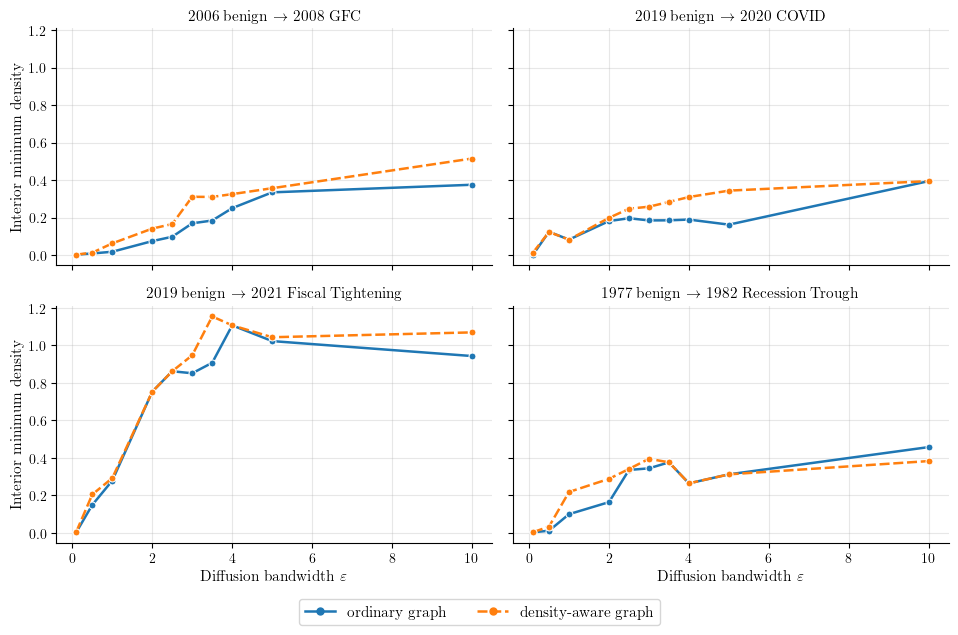

In [ ]:
g = sns.relplot(data=eps_path_df, x="eps", y="interior_minimum_density", hue="path_type", style="path_type",
                col="event_label",col_wrap=2, kind="line", marker="o", height=3.2, aspect=1.25)

g.set_axis_labels(r"Diffusion bandwidth $\varepsilon$", "Interior minimum density")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.grid(alpha=0.3)

handles = g._legend.legend_handles
labels = [text.get_text() for text in g._legend.texts]

g._legend.remove()

g.figure.legend(handles=handles, labels=labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


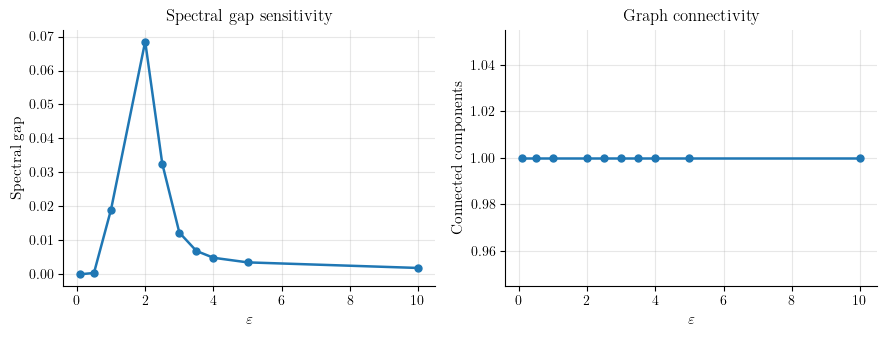

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].plot(eps_embedding_df["eps"], eps_embedding_df["spectral_gap"], marker="o")
axes[0].set_xlabel(r"$\varepsilon$")
axes[0].set_ylabel("Spectral gap")
axes[0].set_title("Spectral gap sensitivity")
axes[0].grid(alpha=0.3)

axes[1].plot(eps_embedding_df["eps"], eps_embedding_df["connected_components"], marker="o")
axes[1].set_xlabel(r"$\varepsilon$")
axes[1].set_ylabel("Connected components")
axes[1].set_title("Graph connectivity")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

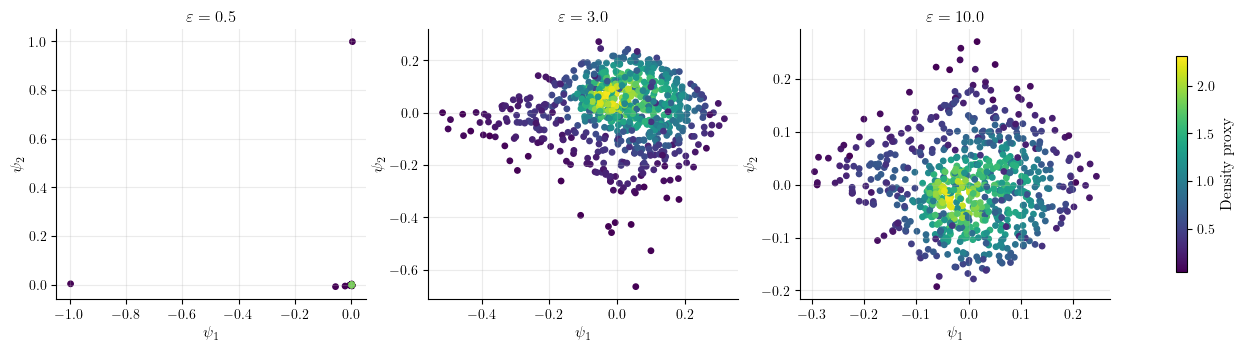

In [ ]:
eps_to_plot = [0.5, 3.0, 10.0]

fig, axes = plt.subplots(1, len(eps_to_plot), figsize=(17, 3.5))

for ax, eps in zip(axes, eps_to_plot):

    Psi_eps = embedding_store[eps]["Psi"]
    rho_eps = embedding_store[eps]["rho"]

    scatter = ax.scatter(Psi_eps[:, 0], Psi_eps[:, 1], c=rho_eps, s=15)

    ax.set_title(rf"$\varepsilon={eps}$")
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")

fig.colorbar(scatter, ax=axes, label="Density proxy", shrink=0.8)

plt.show()